<a href="https://colab.research.google.com/github/ManoelDavy/GeoSense/blob/main/SAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision
!pip install git+https://github.com/facebookresearch/segment-anything
!pip install opencv-python matplotlib

In [ ]:
!mkdir -p modelo
!wget -P modelo https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2026-03-22 01:56:12--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 18.239.50.104, 18.239.50.120, 18.239.50.18, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|18.239.50.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘modelo/sam_vit_b_01ec64.pth’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M   189MB/s    in 1.9s    

2026-03-22 01:56:13 (189 MB/s) - ‘modelo/sam_vit_b_01ec64.pth’ saved [375042383/375042383]



In [ ]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
import torch

model_path = "/content/modelo/sam_vit_b_01ec64.pth"

sam = sam_model_registry["vit_b"](checkpoint=model_path)
sam.to(device="cuda" if torch.cuda.is_available() else "cpu")
mask_generator = SamAutomaticMaskGenerator(sam)

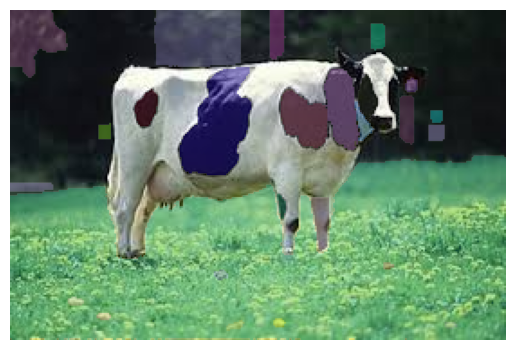

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2

image_path = "/content/images.jpeg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

masks = mask_generator.generate(image)

def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

plt.imshow(image)
show_anns(masks)
plt.axis('off')
plt.show()